# Semana 5 — Consolidación: Control de calidad en planta de producción

Esta sesión consolida las herramientas del módulo a través de un modelo clásico de control de calidad. Primero se estudia el modelo base de dos modos de producción; luego se extiende a **tres variables de estado** para capturar la posición exacta dentro del ciclo de inspección.

Herramientas usadas: `steady_state`, `first_passage_time`, `occupation_time`, `transient_probabilities`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from jmarkov.dtmc import dtmc

---
## Parte 1 — Modelo base: dos modos de producción

### Contexto

Manufactura del Valle S.A.S. opera una línea de producción automatizada que fabrica componentes electrónicos de precisión. Cada artículo producido puede resultar defectuoso con probabilidad $p = 0.086$, de forma **independiente** de los demás artículos.

La planta opera en dos modos que determinan el nivel de supervisión de calidad:

**Modo Costoso (C):** Se inspecciona cada artículo individualmente. Si el artículo es defectuoso, el contador de artículos buenos consecutivos se reinicia a 0. Cuando se acumulan $k = 40$ artículos consecutivos sin defecto, la planta pasa automáticamente al modo Económico. El costo operativo es $C_c = \$1\,000$ por artículo.

**Modo Económico (E):** Para reducir costos de supervisión, cada artículo se inspecciona de forma independiente con probabilidad $1/r = 1/3$. Si en una inspección se detecta un defecto, la planta regresa de inmediato al modo Costoso y el contador se reinicia. El costo operativo es $C_e = \$800$ por artículo.

### Modelamiento como CMTD

$$
X_n = \text{número de artículos consecutivos no defectuosos al momento de producir el artículo } n
$$

$$
\mathcal{S} = \{\underbrace{0, 1, \ldots, k-1}_{\text{modo Costoso}},\; \underbrace{E}_{\text{modo Económico}}\}
\quad \Rightarrow \quad k+1 = 41 \text{ estados}
$$

$$
P_{i \to j} = \begin{cases}
p & j = 0,\; 0 \leq i \leq k-1 & \text{defecto: reinicio al contador 0} \\
1-p & j = i+1,\; 0 \leq i < k-1 & \text{sin defecto: avance del contador} \\
1-p & j = E,\; i = k-1 & \text{$k$ buenos consecutivos: cambio a modo E} \\
\dfrac{p}{r} & j = 0,\; i = E & \text{inspección con defecto: reinicio} \\
1 - \dfrac{p}{r} & j = E,\; i = E & \text{sin defecto (o sin inspección): permanece en E} \\
\end{cases}
$$

### Preguntas de interés

La gerencia de Manufactura del Valle desea responder:

**(b)** La planta termina de producir el artículo $k-1$ (se acumularon $k-1$ buenos consecutivos, modo Costoso). ¿Cuántos de los próximos $N = 200$ artículos se espera que se produzcan en modo Económico?

**(c)** Acaba de detectarse un defecto (reinicio al estado 0). ¿Cuántos artículos se espera producir hasta llegar **por primera vez** al modo Económico?

**(d)** ¿Cuál es el costo esperado por artículo **a largo plazo**?

**(e)** ¿Cuál es la **varianza** del costo por artículo a largo plazo?

**(f)** ¿Cómo evoluciona la probabilidad de estar en modo Económico partiendo desde el estado 0 (reinicio por defecto)?

**a)** Construya la matriz $P$ (41×41) y modele la cadena con `jmarkov`.

In [ ]:
k = 40
r = 3
p = 0.086
n_s   = k + 1      # 41 estados: 0..k-1 (Costoso) + E (indice k)
IDX_E = k          # indice del estado Economico

P = np.zeros((n_s, n_s))

for i in range(n_s):
    if i <= k - 1:                          # Modo Costoso
        P[i, 0] = p                         # defecto -> reinicio
        if i < k - 1:
            P[i, i + 1] = 1 - p             # sin defecto -> avance
        else:
            P[i, IDX_E] = 1 - p             # k consecutivos -> modo E
    else:                                   # Modo Economico (i == k)
        P[i, 0]     = p / r                 # inspeccion con defecto -> reinicio
        P[i, IDX_E] = 1 - p / r             # sin defecto (o sin inspeccion)

cadena = dtmc(P)

# .shape devuelve una tupla con las dimensiones de la matriz P,
# indicando su número de filas y columnas
print('Dimension P     :', P.shape)

# .sum(axis=1) suma los elementos de cada fila de P.
# np.allclose() verifica si todas esas sumas son aproximadamente iguales a 1.0
print('Filas suman a 1 :', np.allclose(P.sum(axis=1), 1.0))
print('Es ergodica     :', cadena.is_ergodic())

Dimension P     : (41, 41)
Filas suman a 1 : True
Es ergodica     : True


**b)** La planta se encuentra en el estado $k-1$ (contador = $k-1$, modo Costoso). ¿Cuántos artículos de los próximos $N = 200$ se espera que se produzcan en modo Económico?

$$
\mathbb{E}\left[\#\text{artículos en modo E en } N=200 \mid X_0 = k-1\right]
= [M(200)]_{k-1,\, E}
$$

In [3]:
N = 200
start_b = k - 1

M_200         = cadena.occupation_time(N)
articulos_E   = float(M_200[start_b, IDX_E])

print(f'Articulos esperados en modo E (N={N}, inicio=k-1): {articulos_E:.4f}')

Articulos esperados en modo E (N=200, inicio=k-1): 40.3414


**c)** Acaba de detectarse un defecto: la planta está en el estado 0. ¿Cuántos artículos se espera producir hasta llegar **por primera vez** al modo Económico?

$$
m_{0,\,E} = \mathbb{E}\!\left[\min\{n>0 : X_n = E\} \mid X_0 = 0\right]
$$

In [4]:
m_0E = float(cadena.first_passage_time(IDX_E)[0])
print(f'Articulos esperados hasta modo E desde estado 0: {m_0E:.2f}')

Articulos esperados hasta modo E desde estado 0: 412.65


C:\Users\abrah\AppData\Local\Temp\ipykernel_40604\2376238559.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  m_0E = float(cadena.first_passage_time(IDX_E)[0])


**d)** Calcule el **costo esperado por artículo a largo plazo** usando la distribución estacionaria:

$$
\mathbb{E}[C] = \sum_{i \in \mathcal{S}} \pi_i \cdot c_i
\qquad \text{donde} \quad
c_i = \begin{cases} C_c = 1\,000 & i \in \{0,\ldots,k-1\} \\ C_e = 800 & i = E \end{cases}
$$

In [ ]:
Cc = 1000
Ce = 800

pi    = cadena.steady_state()
C_vec = np.array([Cc] * k + [Ce])

# np.dot() calcula el producto punto entre el vector de probabilidades pi
# y el vector de costos C_vec, obteniendo el costo esperado
E_costo = np.dot(pi, C_vec)
print(f'Fraccion de tiempo en modo C : {1 - pi[IDX_E]:.4f}  ({(1-pi[IDX_E])*100:.1f}%)')
print(f'Fraccion de tiempo en modo E : {pi[IDX_E]:.4f}  ({pi[IDX_E]*100:.1f}%)')
print(f'Costo esperado por articulo  : ${E_costo:.4f}')

Fraccion de tiempo en modo C : 0.9221  (92.2%)
Fraccion de tiempo en modo E : 0.0779  (7.8%)
Costo esperado por articulo  : $984.4108


**e)** Calcule la **varianza del costo por artículo** a largo plazo:

$$
\text{Var}[C] = \mathbb{E}[C^2] - \left(\mathbb{E}[C]\right)^2
= \sum_{i \in \mathcal{S}} \pi_i \cdot c_i^2 - \left(\sum_{i \in \mathcal{S}} \pi_i \cdot c_i\right)^2
$$

In [6]:
Var_costo = np.dot(pi, C_vec**2) - E_costo**2
print(f'Varianza del costo por articulo    : {Var_costo:.4f}')
print(f'Desviacion estandar del costo      : {Var_costo**0.5:.4f}')

Varianza del costo por articulo    : 2874.8173
Desviacion estandar del costo      : 53.6173


**f)** Grafique cómo evoluciona $P(X_n = E \mid X_0 = 0)$ a lo largo de los primeros 500 artículos. Añada una línea horizontal en $\pi_E$ para mostrar la convergencia.

### 🎨 Visualización proporcionada

La siguiente celda no hace parte de los contenidos de programación evaluados. No es necesario comprender todos los comandos de Matplotlib. Concéntrese en interpretar la convergencia.


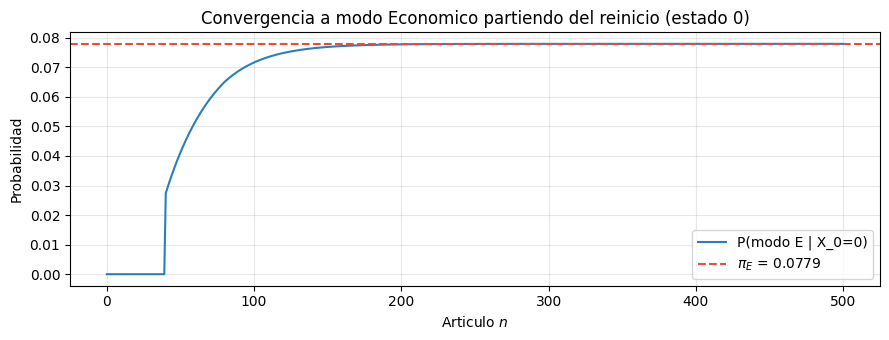

In [7]:
T_plot = 500
alpha0 = np.zeros(n_s); alpha0[0] = 1.0

prob_E = [float(cadena.transient_probabilities(n=n, alpha=alpha0)[IDX_E])
          for n in range(T_plot + 1)]

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(prob_E, color='#2980b9', linewidth=1.5, label='P(modo E | X_0=0)')
ax.axhline(pi[IDX_E], color='#e74c3c', linestyle='--', linewidth=1.5,
           label=f'$\\pi_E$ = {pi[IDX_E]:.4f}')
ax.set_xlabel('Articulo $n$')
ax.set_ylabel('Probabilidad')
ax.set_title('Convergencia a modo Economico partiendo del reinicio (estado 0)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## Parte 2 — Variación: tres variables de estado con ciclo de inspección explícito

### Contexto y motivación

En el modelo base, el estado $E$ agrega toda la dinámica del modo Económico en un único valor, modelando las inspecciones mediante una probabilidad geométrica $1/r$. Esto simplifica el análisis, pero impide conocer en qué **posición del ciclo de inspección** se encuentra la planta en cada momento.

Para una auditoría de calidad más detallada, la gerencia solicita un modelo donde la posición dentro del ciclo de inspección sea una variable de estado explícita. Esto da origen a una cadena con **tres variables de estado**.

### Variables de estado

$$
(i_n,\; m_n,\; j_n)
$$

| Variable | Dominio | Descripción |
|:---:|:---:|---|
| $i_n$ | $\{0, 1, \ldots, k-1\}$ | Artículos buenos consecutivos en modo C |
| $m_n$ | $\{C, E\}$ | Modo de producción |
| $j_n$ | $\{1, 2, \ldots, r\}$ | Posición dentro del ciclo de inspección (modo E) |

En modo C: $j_n = 0$ (variable inactiva). En modo E: $i_n = 0$ y el ciclo es **determinístico**: se producen $r-1$ artículos sin inspección y el artículo $r$ del ciclo se inspecciona. Si no hay defecto, comienza un nuevo ciclo desde $j=1$.

### Espacio de estados con $k=4$, $r=3$

| Índice | Triple $(i, m, j)$ | Descripción |
|:---:|:---:|---|
| 0 | $(0, C, 0)$ | Costoso, contador = 0 |
| 1 | $(1, C, 0)$ | Costoso, contador = 1 |
| 2 | $(2, C, 0)$ | Costoso, contador = 2 |
| 3 | $(3, C, 0)$ | Costoso, contador = 3 — próximo no-defecto activa modo E |
| 4 | $(0, E, 1)$ | Económico, posición 1 del ciclo (sin inspección) |
| 5 | $(0, E, 2)$ | Económico, posición 2 del ciclo (sin inspección) |
| 6 | $(0, E, 3)$ | Económico, posición 3 del ciclo — **inspección** |

### Reglas de transición

**Modo C** ($i = 0,\ldots,k-1$):
$$
P_{(i,C,0) \to s} = \begin{cases}
p & s = 0 & \text{defecto: reinicio} \\
1-p & s = i+1,\; i < k-1 & \text{sin defecto: avance} \\
1-p & s = (E,\,j{=}1),\; i = k-1 & \text{sin defecto al llegar a $k$: modo E}
\end{cases}
$$

**Modo E** ($j = 1,\ldots,r$):
$$
P_{(E,j) \to s} = \begin{cases}
p & s = 0 & \text{defecto en cualquier paso: reinicio a C} \\
1-p & s = (E,\,j{+}1),\; j < r & \text{sin defecto: avance en ciclo} \\
1-p & s = (E,\,j{=}1),\; j = r & \text{inspección sin defecto: nuevo ciclo}
\end{cases}
$$

### Preguntas de interés

**(b)** ¿Se verifica que la razón entre probabilidades estacionarias de estados consecutivos en modo E sigue el patrón $\pi_{(E,j+1)}/\pi_{(E,j)} = 1-p$? ¿Cuál es la razón de tiempo en modo C vs. modo E?

**(c)** Partiendo del estado $(0,C)$, ¿cómo converge la razón de tiempos de ocupación
$$\frac{[M(T)]_{(0,C),\,(E,r)}}{[M(T)]_{(0,C),\,(E,1)}} \xrightarrow{T\to\infty} (1-p)^{r-1}?$$
Muestre la convergencia con una tabla y una gráfica.

**a)** Construya la matriz $P$ (7×7) a partir de las tres variables de estado y cree la cadena.

In [8]:
k_v = 4
r_v = 3
p_v = 0.10

# Indices:
# 0..k_v-1  -> (i, C, 0)  estados modo Costoso
# k_v..k_v+r_v-1  -> (0, E, j)  estados modo Economico (j=1..r)
n_sv   = k_v + r_v          # 7 estados
IDX_E1 = k_v                # (E, j=1) = indice 4
IDX_Er = k_v + r_v - 1      # (E, j=r) = indice 6  <- inspeccion

etiquetas_v = ([f'({i},C)' for i in range(k_v)] +
               [f'(E,j={j+1})' for j in range(r_v)])

P_v = np.zeros((n_sv, n_sv))

# Modo Costoso
for i in range(k_v):
    P_v[i, 0] = p_v
    if i < k_v - 1:
        P_v[i, i + 1] = 1 - p_v
    else:
        P_v[i, IDX_E1] = 1 - p_v

# Modo Economico
for j in range(r_v):
    s = k_v + j
    P_v[s, 0] = p_v
    if j < r_v - 1:
        P_v[s, s + 1] = 1 - p_v
    else:
        P_v[s, IDX_E1] = 1 - p_v   # inspeccion sin defecto -> nuevo ciclo

cadena_v = dtmc(P_v)

print('Estados         :', etiquetas_v)
print('Filas suman a 1 :', np.allclose(P_v.sum(axis=1), 1.0))
print('Es ergodica     :', cadena_v.is_ergodic())
print('\nMatriz P_v:')
print(P_v.round(3))

Estados         : ['(0,C)', '(1,C)', '(2,C)', '(3,C)', '(E,j=1)', '(E,j=2)', '(E,j=3)']
Filas suman a 1 : True
Es ergodica     : True

Matriz P_v:
[[0.1 0.9 0.  0.  0.  0.  0. ]
 [0.1 0.  0.9 0.  0.  0.  0. ]
 [0.1 0.  0.  0.9 0.  0.  0. ]
 [0.1 0.  0.  0.  0.9 0.  0. ]
 [0.1 0.  0.  0.  0.  0.9 0. ]
 [0.1 0.  0.  0.  0.  0.  0.9]
 [0.1 0.  0.  0.  0.9 0.  0. ]]


**b)** Calcule la distribución estacionaria. Verifique que $\pi_{(E,j+1)}/\pi_{(E,j)} = 1-p$ y calcule la razón $f_C / f_E$.

In [9]:
pi_v = cadena_v.steady_state()

print('Distribucion estacionaria:')
for s, (lbl, pis) in enumerate(zip(etiquetas_v, pi_v)):
    print(f'  pi[{lbl:8s}] = {pis:.6f}')

print()
print('Razon pi(E,j+1)/pi(E,j)  vs  teorico (1-p):')
for j in range(r_v - 1):
    razon = pi_v[IDX_E1 + j + 1] / pi_v[IDX_E1 + j]
    print(f'  pi(E,{j+2}) / pi(E,{j+1}) = {razon:.6f}   teorico: {1 - p_v:.6f}')

f_C = pi_v[:k_v].sum()
f_E = pi_v[k_v:].sum()
print(f'\nFraccion en modo C : f_C = {f_C:.4f}')
print(f'Fraccion en modo E : f_E = {f_E:.4f}')
print(f'Razon f_C / f_E    : {f_C / f_E:.4f}')

Distribucion estacionaria:
  pi[(0,C)   ] = 0.100000
  pi[(1,C)   ] = 0.090000
  pi[(2,C)   ] = 0.081000
  pi[(3,C)   ] = 0.072900
  pi[(E,j=1) ] = 0.242103
  pi[(E,j=2) ] = 0.217893
  pi[(E,j=3) ] = 0.196104

Razon pi(E,j+1)/pi(E,j)  vs  teorico (1-p):
  pi(E,2) / pi(E,1) = 0.900000   teorico: 0.900000
  pi(E,3) / pi(E,2) = 0.900000   teorico: 0.900000

Fraccion en modo C : f_C = 0.3439
Fraccion en modo E : f_E = 0.6561
Razon f_C / f_E    : 0.5242


**c)** Partiendo de $(0,C)$, compute $[M(T)]_{(0,C),(E,r)}\,/\,[M(T)]_{(0,C),(E,1)}$ para distintos valores de $T$ y verifique la convergencia al valor teórico $(1-p)^{r-1}$. Presente los resultados en tabla y en gráfica.

### 🎨 Visualización proporcionada

La siguiente celda no hace parte de los contenidos de programación evaluados. No es necesario comprender todos los comandos de Matplotlib.

Valor teorico (1-p)^(r-1) = 0.810000

       T   M(E,r)/M(E,1)   Error absoluto
      10   0.579233       0.230767
      25   0.736878       0.073122
      50   0.776056       0.033944
     100   0.793457       0.016543
     200   0.801815       0.008185
     500   0.806747       0.003253
    1000   0.808377       0.001623
    2000   0.809189       0.000811


<>:18: SyntaxWarning: "\," is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\,"? A raw string is also an option.
<>:18: SyntaxWarning: "\," is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\,"? A raw string is also an option.
C:\Users\abrah\AppData\Local\Temp\ipykernel_40604\2279981811.py:18: SyntaxWarning: "\," is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\,"? A raw string is also an option.
  label='$[M(T)]_{(0,C),(E,r)}\,/\,[M(T)]_{(0,C),(E,1)}$')


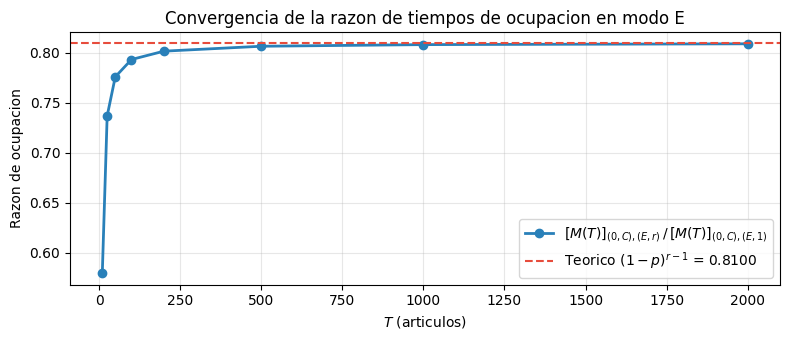

In [10]:
T_vals    = [10, 25, 50, 100, 200, 500, 1000, 2000]
teorico   = (1 - p_v) ** (r_v - 1)
razones   = []

for T in T_vals:
    M_T  = cadena_v.occupation_time(T)
    r_T  = float(M_T[0, IDX_Er]) / float(M_T[0, IDX_E1])
    razones.append(r_T)

print(f'Valor teorico (1-p)^(r-1) = {teorico:.6f}')
print()
print(f'  {"T":>6}   M(E,r)/M(E,1)   Error absoluto')
for T, rz in zip(T_vals, razones):
    print(f'  {T:>6}   {rz:.6f}       {abs(rz - teorico):.6f}')

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(T_vals, razones, marker='o', color='#2980b9', linewidth=2,
        label='$[M(T)]_{(0,C),(E,r)}\,/\,[M(T)]_{(0,C),(E,1)}$')
ax.axhline(teorico, color='#e74c3c', linestyle='--', linewidth=1.5,
           label=f'Teorico $(1-p)^{{r-1}}$ = {teorico:.4f}')
ax.set_xlabel('$T$ (articulos)')
ax.set_ylabel('Razon de ocupacion')
ax.set_title('Convergencia de la razon de tiempos de ocupacion en modo E')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## Ejercicio abierto — Control de calidad con desgaste de máquina (tres variables de estado)

### Contexto

Textiles Andes S.A.S. opera telares automatizados que producen rollos de tela. Cada rollo puede tener un defecto de fabricación con una probabilidad que **depende del estado del telar**: cuando el telar está en buen estado (*Good*, G) la probabilidad de defecto es $p_G = 0.05$; cuando está desgastado (*Worn*, W) la probabilidad sube a $p_W = 0.18$.

La planta usa la misma lógica de dos modos del ejercicio anterior, pero ahora el contador de artículos buenos y el modo de producción coexisten con el **estado de desgaste del telar**, que evoluciona de forma estocástica en cada período:

- Con probabilidad $d = 0.04$ el telar G se desgasta y pasa a W (degradación).
- Con probabilidad $u = 0.12$ el telar W es reparado y vuelve a G (mantenimiento reactivo).

El modo de producción sigue la misma regla: $k = 3$ buenos consecutivos activan el modo E, que usa un ciclo de inspección determinístico de $r = 2$ artículos (el segundo se inspecciona). Si se detecta un defecto (con la probabilidad correspondiente al estado del telar), la planta regresa a modo C.

Los costos operativos siguen siendo $C_c = \$1\,000$ (modo C) y $C_e = \$800$ (modo E) por artículo.

### Variable de estado conjunta

$$
(i_n,\; m_n,\; w_n)
$$

| Variable | Dominio | Descripción |
|:---:|:---:|---|
| $i_n$ | $\{0,\ldots,k-1\}$ en modo C; $\{1,\ldots,r\}$ en modo E | Contador C / posición ciclo E |
| $m_n$ | $\{C, E\}$ | Modo de producción |
| $w_n$ | $\{G, W\}$ | Estado del telar |

Estados ($k=3$, $r=2$): $(0,C,G)$, $(0,C,W)$, $(1,C,G)$, $(1,C,W)$, $(2,C,G)$, $(2,C,W)$, $(1,E,G)$, $(1,E,W)$, $(2,E,G)$, $(2,E,W)$ — **10 estados en total**.

### Reglas de transición

Para cada transición, el contador/ciclo evoluciona según la lógica del modo, y el estado del telar evoluciona **independientemente**:

$$
P_{(i,m,w)\to(i',m',w')} = P_{\text{contador}}(i,m,w \to i',m') \times P_{\text{telar}}(w \to w')
$$

donde:
$$
P_{\text{telar}}(G \to G) = 1-d, \quad P_{\text{telar}}(G \to W) = d, \quad
P_{\text{telar}}(W \to G) = u, \quad P_{\text{telar}}(W \to W) = 1-u
$$

y $P_{\text{contador}}$ sigue la misma lógica del modelo base con $p_G$ o $p_W$ según $w$.

### Preguntas de interés

1. Construya la matriz $P$ (10×10) e implemente la cadena con `jmarkov`.
2. Calcule la distribución estacionaria $\boldsymbol{\pi}$.    ¿Qué fracción del tiempo opera la planta en modo E con telar G vs. en modo E con telar W?
3. ¿Cuántos artículos se espera producir hasta llegar por primera vez al modo E    (desde el estado $(0,C,G)$)? Calcule $m_{(0,C,G),\,(1,E,G)} + m_{(0,C,G),\,(1,E,W)}$    sumando los primeros tiempos de pasada a cada sub-estado E.
4. Compute el tiempo de ocupación $M(T=100)$ desde $(0,C,G)$.    Calcule la razón:
   $$\frac{\sum_{w\in\{G,W\}} [M(100)]_{(0,C,G),(2,E,w)}}{\sum_{w\in\{G,W\}} [M(100)]_{(0,C,G),(1,E,w)}}$$
   Interprete su valor a la luz del desgaste del telar y compárelo con el caso sin desgaste ($d=0$).

### Cómo usar una IA para resolver este ejercicio

Este ejercicio tiene tres variables de estado con dinámica cruzada: la lógica del modo de producción depende de $w$ (desgaste), y el desgaste evoluciona independientemente. El éxito del prompt depende de que la indexación y las reglas de transición estén **completamente derivadas en papel antes de enviar**.

---

**Ejemplo de prompt bien construido:**

```
Estoy modelando una planta textil como una CMTD con tres variables de estado.
Uso la notacion de mi curso:

  Variable de estado: (i_n, m_n, w_n)
  Espacio de estados (10 estados, indexacion 0-based):
    s=0: (0,C,G)  s=1: (0,C,W)  s=2: (1,C,G)  s=3: (1,C,W)
    s=4: (2,C,G)  s=5: (2,C,W)  s=6: (1,E,G)  s=7: (1,E,W)
    s=8: (2,E,G)  s=9: (2,E,W)

  P[i,j] = P(X_{n+1}=j | X_n=i)  (fila i, columna j)

Parametros:
  k=3, r=2, p_G=0.05, p_W=0.18, d=0.04 (G->W), u=0.12 (W->G)

Regla de transicion (derivada en papel):
  P[(i,m,w) -> (i',m',w')] = P_cont(i,m,w -> i',m') * P_telar(w -> w')

  P_telar: G->G=0.96, G->W=0.04, W->G=0.12, W->W=0.88

  P_cont en modo C (defecto prob = p_G si w=G, p_W si w=W):
    defecto (prob p_w):       i'=0, m'=C
    sin def y i<k-1 (1-p_w): i'=i+1, m'=C
    sin def y i=k-1 (1-p_w): i'=1, m'=E  <- primer ciclo E

  P_cont en modo E, posicion j (defecto prob = p_G si w=G, p_W si w=W):
    defecto (prob p_w):       i'=0, m'=C
    sin def y j<r (1-p_w):   i'=j+1, m'=E
    sin def y j=r (1-p_w):   i'=1, m'=E  <- nuevo ciclo E

Necesito que me ayudes a:
1. Construir P como np.ndarray (10x10) con el producto P_cont * P_telar
   y verificar que las filas sumen 1.
2. Crear: from jmarkov.dtmc import dtmc -> cadena = dtmc(P)
3. Calcular steady_state(). Reportar:
   - fraccion en modo E con telar G: sum(pi[s] for s in [6,8])
   - fraccion en modo E con telar W: sum(pi[s] for s in [7,9])
4. Calcular first_passage_time para los sub-estados E:
   m = cadena.first_passage_time(target)
   reportar m[0] (desde s=0=(0,C,G)) para target in [6,7,8,9]
   y calcular tiempo hasta llegar a cualquier E:
   t_E = m[0,6] + m[0,7]  (suma de primeras pasadas a (1,E,G) y (1,E,W))
5. Calcular occupation_time(100). Desde s=0:
   M_E2 = M[0,8] + M[0,9]  # suma sobre w de (2,E,w)
   M_E1 = M[0,6] + M[0,7]  # suma sobre w de (1,E,w)
   razon = M_E2 / M_E1
   Repetir con d=0 (sin desgaste) y comparar.

Usa unicamente numpy y jmarkov. Muestra resultados en tablas claras.
Comenta cada bloque indicando que calcula.
```

---

> **Por que este prompt funciona:**
> La indexacion de los 10 estados esta completamente definida antes de enviar.
> La factorizacion $P = P_{\text{cont}} \times P_{\text{telar}}$ esta derivada en papel.
> Las preguntas usan indices exactos del vector de estados (e.g., `sum(pi[s] for s in [6,8])`).
> Se pide comparacion con $d=0$ lo que hace que la IA entienda el objetivo de sensibilidad.

In [11]:
# Tu solución aquí


---
<small>Universidad de los Andes · Departamento de Ingeniería Industrial · Modelos de Decisión en el Tiempo</small>